In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-tz6luni9
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-tz6luni9
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [14]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Detectar si hay GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"

# Cargar modelo CLIP preentrenado
model, preprocess = clip.load("ViT-B/32", device=device)



In [15]:
# Subir imágenes desde tu PC
from google.colab import files
uploaded = files.upload()

# Lista de rutas de las imágenes subidas
image_paths = list(uploaded.keys())


Saving black_pants.jpg to black_pants.jpg
Saving blue_jeans.jpg to blue_jeans.jpg
Saving red_dress.jpg to red_dress.jpg
Saving red_tshirt.jpg to red_tshirt.jpg
Saving white_dress.jpg to white_dress.jpg
Saving white_tshirt.jpg to white_tshirt.jpg


In [16]:
image_paths = list(uploaded.keys())


In [17]:
# Descripciones textuales que usarás como etiquetas
descripciones = [
    "a red t-shirt",           # red_tshirt.jpg
    "a pair of blue jeans",    # blue_jeans.jpg
    "a white dress",           # white_dress.jpg
    "a white t-shirt",         # white_tshirt.jpg
    "a red dress",             # red_dress.jpg
    "a pair of black pants"    # black_pants.jpg
]

# Tokenizar descripciones
text_inputs = clip.tokenize(descripciones).to(device)


In [18]:
# Clasificar cada imagen contra las descripciones
for path in image_paths:
    image = preprocess(Image.open(path)).unsqueeze(0).to(device)

    with torch.no_grad():
        logits_per_image, _ = model(image, text_inputs)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    print(f"\n🖼️ Imagen: {path}")
    for i, desc in enumerate(descripciones):
        print(f"→ {desc}: {probs[i]*100:.2f}%")



🖼️ Imagen: black_pants.jpg
→ a red t-shirt: 0.01%
→ a pair of blue jeans: 0.82%
→ a white dress: 0.00%
→ a white t-shirt: 0.01%
→ a red dress: 0.00%
→ a pair of black pants: 99.16%

🖼️ Imagen: blue_jeans.jpg
→ a red t-shirt: 0.00%
→ a pair of blue jeans: 99.87%
→ a white dress: 0.00%
→ a white t-shirt: 0.01%
→ a red dress: 0.00%
→ a pair of black pants: 0.12%

🖼️ Imagen: red_dress.jpg
→ a red t-shirt: 0.89%
→ a pair of blue jeans: 0.00%
→ a white dress: 0.02%
→ a white t-shirt: 0.00%
→ a red dress: 99.09%
→ a pair of black pants: 0.00%

🖼️ Imagen: red_tshirt.jpg
→ a red t-shirt: 99.61%
→ a pair of blue jeans: 0.00%
→ a white dress: 0.00%
→ a white t-shirt: 0.38%
→ a red dress: 0.00%
→ a pair of black pants: 0.00%

🖼️ Imagen: white_dress.jpg
→ a red t-shirt: 0.00%
→ a pair of blue jeans: 0.08%
→ a white dress: 94.99%
→ a white t-shirt: 4.91%
→ a red dress: 0.01%
→ a pair of black pants: 0.01%

🖼️ Imagen: white_tshirt.jpg
→ a red t-shirt: 0.12%
→ a pair of blue jeans: 0.00%
→ a white dr

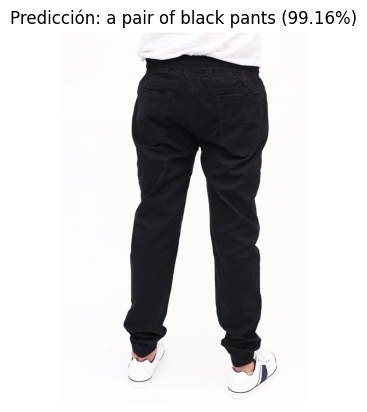

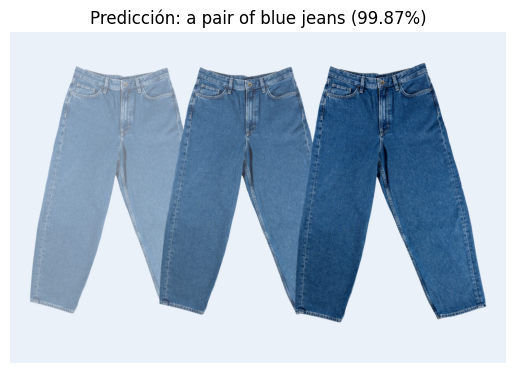

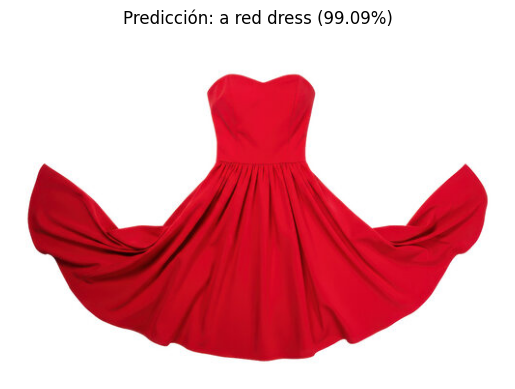

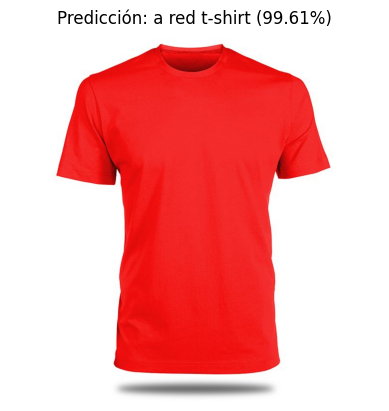

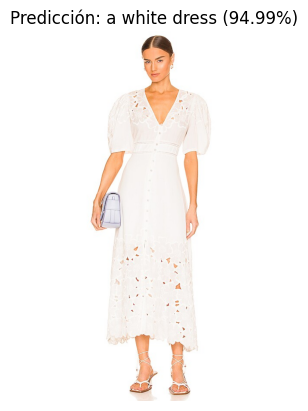

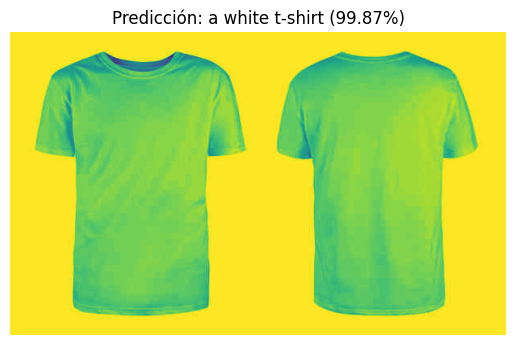

In [19]:
# Visualizar imagen y predicción más probable
for path in image_paths:
    image = preprocess(Image.open(path)).unsqueeze(0).to(device)

    with torch.no_grad():
        logits_per_image, _ = model(image, text_inputs)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)

    img = Image.open(path)
    plt.imshow(img)
    plt.title(f"Predicción: {descripciones[pred_idx]} ({probs[pred_idx]*100:.2f}%)")
    plt.axis("off")
    plt.show()


In [20]:
from torchvision import models, transforms
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Cargar modelo ResNet18 sin la última capa (solo para extraer features)
resnet = models.resnet18(pretrained=True)
resnet.fc = torch.nn.Identity()
resnet.eval().to(device)

# Transformación para entrada de ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

imagenes = []
etiquetas = []

# ✅ Diccionario de etiquetas fijas por nombre de archivo
# Asegúrate de que los nombres coincidan exactamente con los que subiste
etiquetas_dict = {
    "red_tshirt.jpg": 0,       # camiseta
    "white_tshirt.jpg": 0,     # camiseta
    "blue_jeans.jpg": 1,       # jeans
    "white_dress.jpg": 2,      # vestido
    "red_dress.jpg": 2,        # vestido
    "black_pants.jpg": 3       # pantalón
}

# Extraer features y asignar etiquetas
for path in image_paths:
    img = Image.open(path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feature = resnet(tensor).squeeze().cpu().numpy()
    imagenes.append(feature)

    # 🟢 Asignar etiqueta exacta
    etiquetas.append(etiquetas_dict[path])



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [21]:
# Entrenar un clasificador SVM con los embeddings
clf = SVC(kernel="linear")
clf.fit(imagenes, etiquetas)

# Evaluar sobre las mismas imágenes
preds = clf.predict(imagenes)
print("Precisión del clasificador tradicional (SVM):", accuracy_score(etiquetas, preds))


Precisión del clasificador tradicional (SVM): 1.0
